# Fitting the wavelet modulation model to the GF envelope

**Stage 2.** Can the wavelet modulation model of `bahamas.wavelet` represent the true Galactic-foreground modulation from
[cyclo_fig7_modulation.ipynb](cyclo_fig7_modulation.ipynb)? That modulation is the cyclo pack-2 injection, i.e. the Fig. 7
envelope. The model, [`WaveletModulation`](../bahamas/wavelet/model.py), is

$$\log P_c(t) = b_c + \sum_{k=1}^{K} a_k\,\psi\!\left(\frac{t-t_k}{\tau_k}\right),\qquad t_k = t_0 + t_{\rm frac,k}\,T,$$

with Gaussian (default) or Ricker atoms $\psi$. The target is $P_c(t) = M_c^2(t)$ from `envelopes_gaussian`.

This is a **deterministic fit to the noiseless truth**, not an inference: least squares in $\log P$ with the same
parameter ranges as the inference prior in `template/config_wavelet.yaml` (widths 5–180 d, amplitudes $\pm3$,
$t_{\rm frac}\in[0,1]$, level $\pm2$). It tells us how many atoms the envelope needs, and gives starting/reference atoms
for stage 3 (injection and recovery).

Two windows:
* **full first year**, the length of the wavelet template config;
* **cyclo pack-2 window** (first 30 d), the data Riccardo's chunked run used.

In [1]:
from pathlib import Path
import time
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
jax.config.update('jax_enable_x64', True)
from scipy.optimize import minimize

from bahamas.wavelet.model import WaveletModulation, DAY

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
OUT = ROOT / 'data' / 'cyclo_fig7_outputs'
YEAR = 31557600.0

truth = np.load(OUT / 'gf_modulation_truth.npz', allow_pickle=True)
t_hour = truth['t_hour']
P_true = np.stack([truth['P_A'], truth['P_E']])
CH = 'AE'

# prior ranges of template/config_wavelet.yaml
WIDTH_DAYS, AMP_RANGE, LEVEL_RANGE = (5., 180.), (-3., 3.), (-2., 2.)
WINDOWS = {'year': (0., YEAR), 'pack2': (0., float(truth['pack_T']))}
K_MAX = {'year': 9, 'pack2': 4}
RMS_TARGET = 0.01      # 1% rms in P: well below the ~1.5% precision of a 15 d chunk estimate (see §3)

C_TRUTH, C_FIT, C_SECOND, C_MUTED = '#0b0b0b', '#2a78d6', '#eb6834', '#52514e'
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25, 'axes.spines.top': False,
                     'axes.spines.right': False, 'lines.linewidth': 1.5, 'legend.frameon': False})

2026-10-09 11:15:33,578 - BAHAMAS - INFO - Using JAX backend.


2026-10-09 11:15:33,579 - BAHAMAS - INFO - np is from: jax.numpy


## 1. Fitting procedure

For each window, channel and atom shape, $K$ goes up from 0. The fit of $K$ atoms is started from (i) the best $K-1$ fit
plus one atom placed at the largest residual (greedy, matching-pursuit style), and (ii) 20 random draws from the prior.
Each start is refined with L-BFGS-B using exact JAX gradients, and the best result is kept. The loss is the mean squared
error of $\log P$ on the hourly grid.

The level $b_c$ is left free for **both** channels here. In the inference $b_A\equiv0$, because it is degenerate with
the galactic amplitude, so the A level found here becomes an amplitude shift
$\Delta\log_{10}A = b_A/\ln 10$ (see §4).

In [2]:
def unpack(theta, K):
    return theta[0], (theta[1:].reshape(K, 3) if K else None)

def fit_window(window, c, K, shape='gaussian', prev=None, restarts=20, seed=0):
    t0, T = WINDOWS[window]
    sel = (t_hour >= t0) & (t_hour < t0 + T)
    t, y = jnp.asarray(t_hour[sel]), jnp.log(P_true[c, sel])
    wm = WaveletModulation(t0, T, shape)

    def loss(theta):
        level, atoms = unpack(theta, K)
        return jnp.mean((wm.log_modulation(t, atoms, level=level) - y) ** 2)
    vg = jax.jit(jax.value_and_grad(loss))
    fun = lambda th: tuple(np.asarray(v, float) for v in vg(jnp.asarray(th)))
    bounds = [LEVEL_RANGE] + [(0., 1.), tuple(np.log10(WIDTH_DAYS)), AMP_RANGE] * K

    rng = np.random.default_rng(seed)
    starts = []
    if prev is not None:
        level, atoms = unpack(prev, K - 1)
        res = np.asarray(y - wm.log_modulation(t, atoms, level=level))
        i = np.argmax(np.abs(res))
        starts.append(np.concatenate([prev, [(np.asarray(t)[i] - t0) / T, np.log10(30.), np.clip(res[i], *AMP_RANGE)]]))
    for _ in range(restarts):
        starts.append(np.array([float(jnp.mean(y))] + [v for _ in range(K) for v in
                               (rng.uniform(0, 1), rng.uniform(*np.log10(WIDTH_DAYS)), rng.uniform(-1, 1))]))
    best = min((minimize(fun, s, jac=True, method='L-BFGS-B', bounds=bounds, options={'maxiter': 3000}) for s in starts),
               key=lambda r: r.fun)
    level, atoms = unpack(best.x, K)
    model = np.asarray(wm.log_modulation(t, atoms, level=level))
    rel = np.exp(model - np.asarray(y)) - 1
    return dict(theta=best.x, rms=float(np.sqrt(best.fun)), max_rel=float(np.max(np.abs(rel))),
                t=np.asarray(t), P_fit=np.exp(model), P_true=np.exp(np.asarray(y)), wm=wm)

scan = {}
for shape in ('gaussian', 'ricker'):
    for window in WINDOWS:
        for c, ch in enumerate(CH):
            prev, t1 = None, time.time()
            for K in range(K_MAX[window]):
                r = fit_window(window, c, K, shape, prev=prev)
                scan[shape, window, ch, K] = r
                prev = r['theta']
            print(f"{shape:8s} {window:5s} {ch}: " + '  '.join(f"K={K}:{scan[shape, window, ch, K]['rms']:.4f}"
                                                         for K in range(K_MAX[window])) + f"   ({time.time()-t1:.0f} s)")

gaussian year  A: K=0:0.6424  K=1:0.5086  K=2:0.1293  K=3:0.0709  K=4:0.0375  K=5:0.0188  K=6:0.0053  K=7:0.0040  K=8:0.0022   (108 s)


gaussian year  E: K=0:0.4375  K=1:0.3420  K=2:0.0592  K=3:0.0295  K=4:0.0113  K=5:0.0054  K=6:0.0034  K=7:0.0025  K=8:0.0019   (86 s)


gaussian pack2 A: K=0:0.3444  K=1:0.0160  K=2:0.0023  K=3:0.0002   (2 s)


gaussian pack2 E: K=0:0.0709  K=1:0.0031  K=2:0.0001  K=3:0.0001   (5 s)


ricker   year  A: K=0:0.6424  K=1:0.4404  K=2:0.1234  K=3:0.0673  K=4:0.0203  K=5:0.0200  K=6:0.0108  K=7:0.0062  K=8:0.0050   (119 s)


ricker   year  E: K=0:0.4375  K=1:0.2972  K=2:0.1114  K=3:0.0469  K=4:0.0159  K=5:0.0035  K=6:0.0036  K=7:0.0035  K=8:0.0021   (103 s)


ricker   pack2 A: K=0:0.3444  K=1:0.0187  K=2:0.0005  K=3:0.0003   (2 s)


ricker   pack2 E: K=0:0.0709  K=1:0.0022  K=2:0.0001  K=3:0.0001   (2 s)


## 2. How many atoms are needed?

The rms error of $\log P$ is close to the rms relative error of $P$. The dotted line marks the 1% target.

smallest K reaching rms < 1%:
  gaussian year  A: K = 6  (rms 0.0053, max|dP/P| 0.0394)
  gaussian year  E: K = 5  (rms 0.0054, max|dP/P| 0.0301)
  gaussian pack2 A: K = 2  (rms 0.0023, max|dP/P| 0.0078)
  gaussian pack2 E: K = 1  (rms 0.0031, max|dP/P| 0.0091)
  ricker   year  A: K = 7  (rms 0.0062, max|dP/P| 0.0452)
  ricker   year  E: K = 5  (rms 0.0035, max|dP/P| 0.0178)
  ricker   pack2 A: K = 2  (rms 0.0005, max|dP/P| 0.0016)
  ricker   pack2 E: K = 1  (rms 0.0022, max|dP/P| 0.0076)


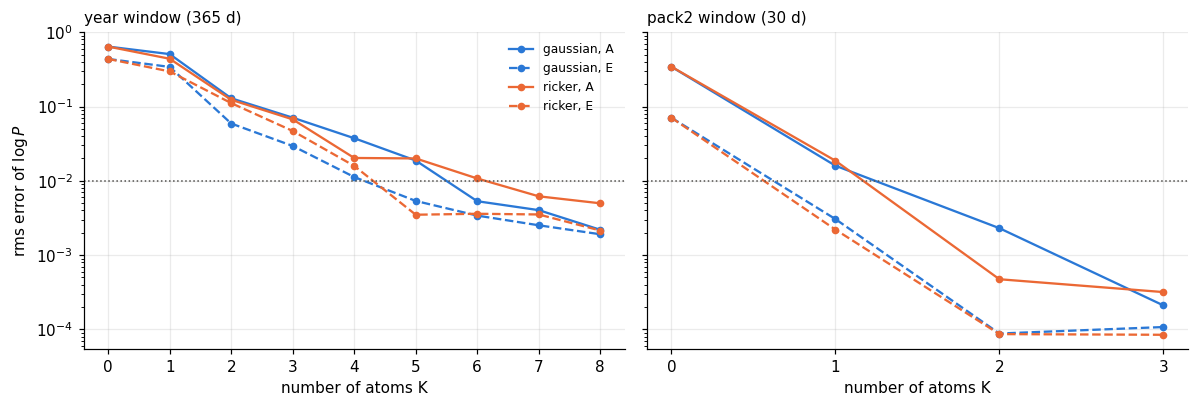

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
styles = {('gaussian', 'A'): (C_FIT, '-'), ('gaussian', 'E'): (C_FIT, '--'),
          ('ricker', 'A'): (C_SECOND, '-'), ('ricker', 'E'): (C_SECOND, '--')}
for ax, window in zip(axes, WINDOWS):
    Ks = np.arange(K_MAX[window])
    for (shape, ch), (col, ls) in styles.items():
        ax.semilogy(Ks, [scan[shape, window, ch, K]['rms'] for K in Ks], color=col, ls=ls, marker='o', ms=4,
                    label=f'{shape}, {ch}')
    ax.axhline(RMS_TARGET, color=C_MUTED, ls=':', lw=1)
    ax.set_xlabel('number of atoms K')
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.set_title(f'{window} window ({WINDOWS[window][1]/DAY:.0f} d)', loc='left', fontsize=10)
axes[0].set_ylabel(r'rms error of $\log P$')
axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / 'wavelet_fit_rms_vs_K.png', bbox_inches='tight')

K_SEL = {}
print(f"smallest K reaching rms < {RMS_TARGET:.0%}:")
for shape in ('gaussian', 'ricker'):
    for window in WINDOWS:
        for ch in CH:
            ok = [K for K in range(K_MAX[window]) if scan[shape, window, ch, K]['rms'] < RMS_TARGET]
            K_SEL[shape, window, ch] = ok[0] if ok else K_MAX[window] - 1
            r = scan[shape, window, ch, K_SEL[shape, window, ch]]
            print(f"  {shape:8s} {window:5s} {ch}: K = {K_SEL[shape, window, ch]}  (rms {r['rms']:.4f}, max|dP/P| {r['max_rel']:.4f})")

## 3. Best fits (Gaussian atoms)

For each panel: the truth and the fit (top), the relative residual in % (middle), and the individual atoms
$a_k\psi_k$ in $\log P$ (bottom). The grey band in the residual panel is the median $\pm1\sigma$ precision of a 15-day
chunk estimate of $\bar M^c$ from the GF-only time series (§4b of the first notebook). A fit residual well inside it
means the model error is negligible next to what the data can resolve.

In [4]:
chunk_prec = np.median(np.concatenate([truth['Pbar_err_A'] / truth['Pbar_A'], truth['Pbar_err_E'] / truth['Pbar_E']]))
print(f"median relative precision of a 15 d chunk estimate: {chunk_prec:.2%}")

def plot_fit(window, shape='gaussian'):
    fig, axes = plt.subplots(3, 2, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1.2]})
    for c, ch in enumerate(CH):
        K = K_SEL[shape, window, ch]
        r = scan[shape, window, ch, K]
        level, atoms = unpack(r['theta'], K)
        td = r['t'] / DAY
        P_t = r['P_true']
        ax0, ax1, ax2 = axes[:, c]
        ax0.plot(td, P_t, color=C_TRUTH, label=r'true $M^2(t)$')
        ax0.plot(td, r['P_fit'], color=C_FIT, ls='--', label=f'wavelet fit, K = {K}')
        ax0.set_title(f'{ch} channel', loc='left', fontsize=10)
        ax0.set_ylabel(r'$P(t)$')
        ax1.axhspan(-100 * chunk_prec, 100 * chunk_prec, color=C_MUTED, alpha=0.15, lw=0, label='15 d chunk precision')
        ax1.plot(td, 100 * (r['P_fit'] / P_t - 1), color=C_FIT)
        ax1.set_ylabel(r'$\Delta P/P$ [%]')
        ax2.axhline(level, color=C_MUTED, lw=1, ls=':', label=f'level b = {level:+.3f}')
        for k in range(K):
            ax2.plot(td, np.asarray(r['wm'].log_modulation(r['t'], atoms[k:k+1], level=0.)), lw=1.2)
        ax2.set_ylabel(r'atoms in $\log P$')
        ax2.set_xlabel('time [days]')
        ax0.legend(fontsize=8)
        ax1.legend(fontsize=8, loc='lower right')
        ax2.legend(fontsize=8, loc='lower right')
    fig.suptitle(f'{shape} wavelet fit, {window} window', y=0.995)
    fig.tight_layout()
    fig.savefig(OUT / f'wavelet_fit_{window}_{shape}.png', bbox_inches='tight')

def atom_table(window, shape='gaussian'):
    for ch in CH:
        K = K_SEL[shape, window, ch]
        level, atoms = unpack(scan[shape, window, ch, K]['theta'], K)
        t0, T = WINDOWS[window]
        flag = ' <- at prior bound' if np.isclose(abs(level), LEVEL_RANGE[1]) else ''
        print(f"{window} {ch}: level b = {level:+.4f}{flag}")
        print(f"   {'k':>2s} {'t_frac':>7s} {'centre[d]':>9s} {'width[d]':>9s} {'amp':>7s}")
        for k, (tf, lw, a) in enumerate(atoms if K else []):
            edge = ' <- at prior bound' if (np.isclose(lw, np.log10(WIDTH_DAYS)).any() or np.isclose(abs(a), 3)
                                             or tf in (0., 1.)) else ''
            print(f"   {k:2d} {tf:7.3f} {(t0 + tf*T)/DAY:9.1f} {10**lw:9.1f} {a:+7.3f}{edge}")

median relative precision of a 15 d chunk estimate: 1.99%


year A: level b = -0.0822
    k  t_frac centre[d]  width[d]     amp
    0   0.988     360.8      16.1  -0.776
    1   0.458     167.3      17.9  -0.666
    2   0.731     267.1      69.7  +2.455
    3   0.464     169.3      34.7  -0.294
    4   0.232      84.9      57.8  +2.161
    5   0.000       0.0      14.8  -0.537 <- at prior bound
year E: level b = +1.9022
    k  t_frac centre[d]  width[d]     amp
    0   0.524     191.3      17.2  -0.290
    1   0.998     364.7      35.9  -0.990
    2   0.029      10.5      28.3  -1.019
    3   0.512     186.9      44.2  -1.682
    4   0.545     199.2      75.0  +1.183


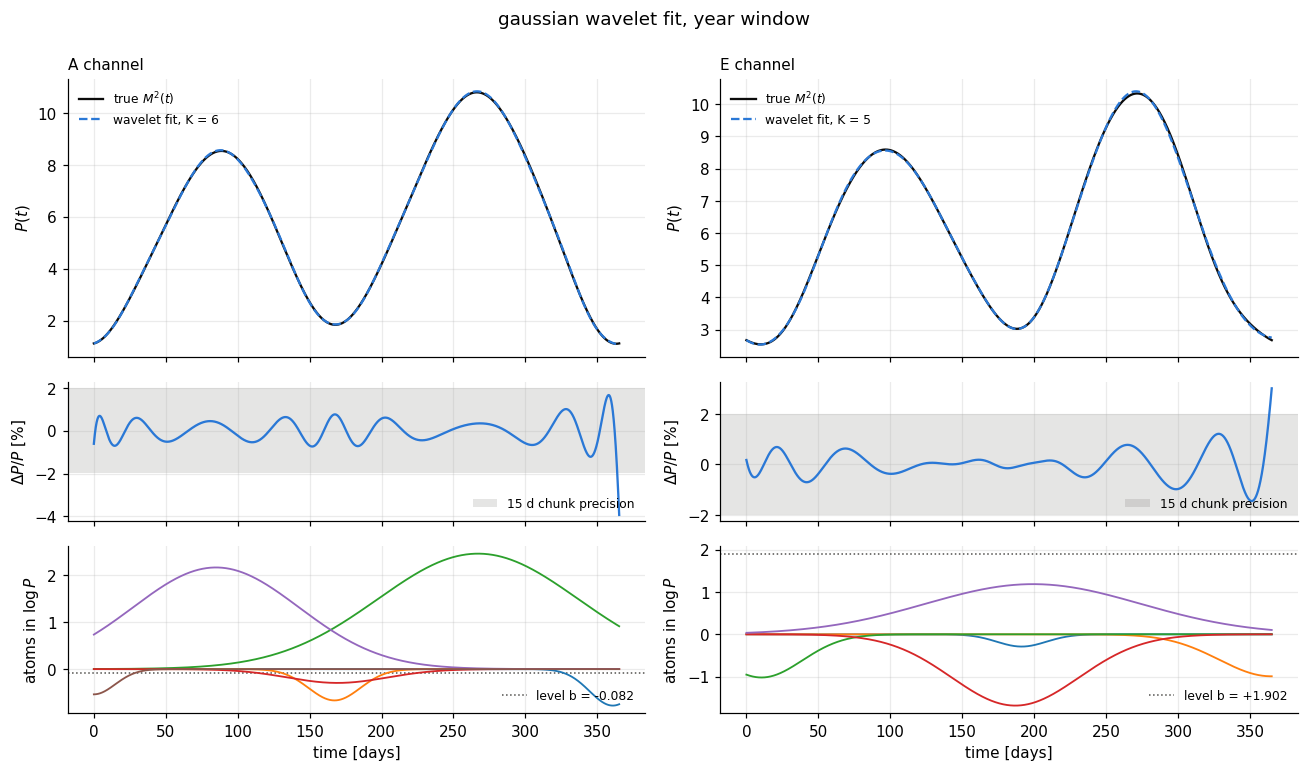

In [5]:
plot_fit('year')
atom_table('year')

pack2 A: level b = +1.5567
    k  t_frac centre[d]  width[d]     amp
    0   0.007       0.2      17.3  -2.407
    1   0.134       4.0      14.7  +1.001
pack2 E: level b = +2.0000 <- at prior bound
    k  t_frac centre[d]  width[d]     amp
    0   0.321       9.6      27.9  -1.069


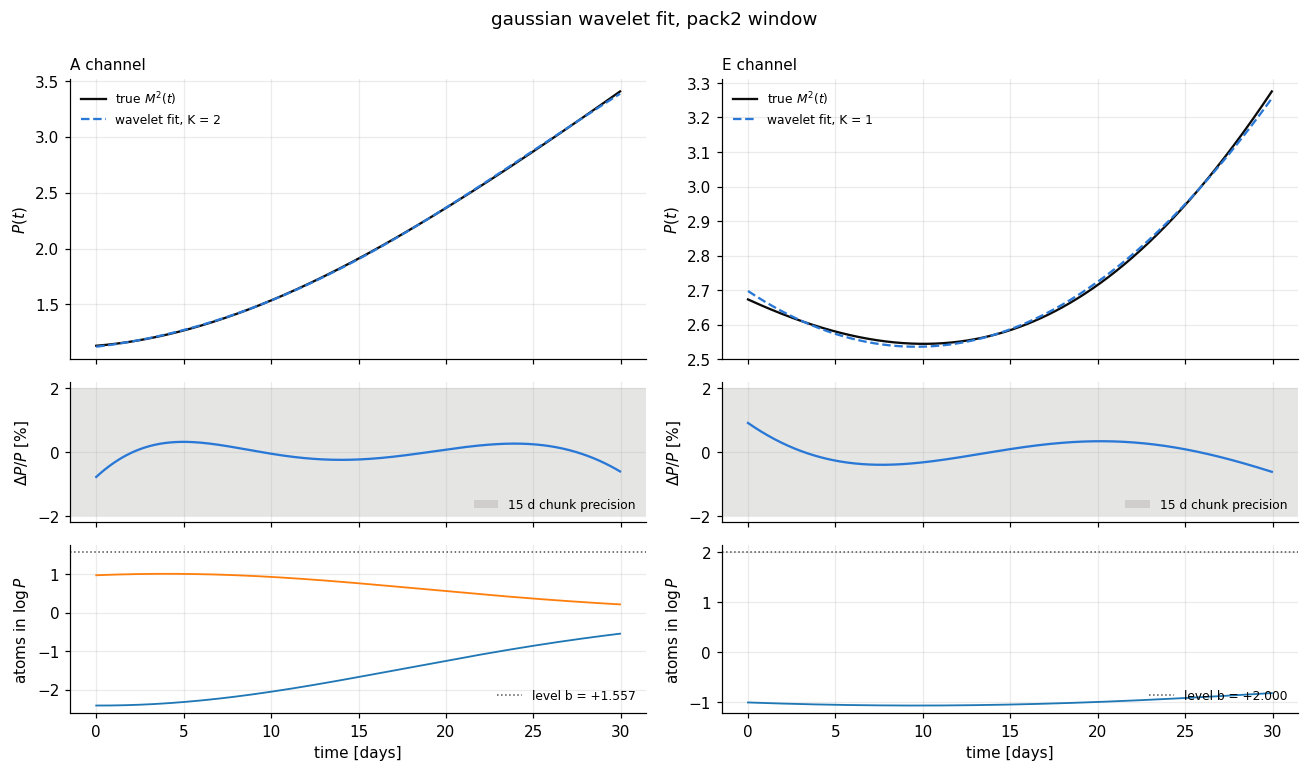

In [6]:
plot_fit('pack2')
atom_table('pack2')

### The fit in the Fig. 7 picture

The data are $x(t) = M(t)\,n(t)$, a zero-mean signal with instantaneous standard deviation $\sigma M(t)$. The upper and
lower envelopes $\pm3\sigma M(t)$ are mirror images, so the two-sided Fig. 7 envelope carries exactly the information in
$M^2(t)$. The fitted model therefore gives the Fig. 7 envelope directly as $\pm3\sigma\sqrt{P_{\rm fit}(t)}$, with no
separate fit.

Below, the light-blue band is the hourly min/max of the simulated GF from the first notebook. The ink line is the true
$\pm3\sigma M(t)$ and the dashed line is the wavelet fit. The small panels show the envelope residual
$\Delta M/M = \sqrt{P_{\rm fit}/P_{\rm true}} - 1 \approx \tfrac12\,\Delta P/P$, half the residual of §3.

year A: envelope residual rms 0.27%, max 1.99%
year E: envelope residual rms 0.27%, max 1.49%


pack2 A: envelope residual rms 0.12%, max 0.39%
pack2 E: envelope residual rms 0.15%, max 0.45%


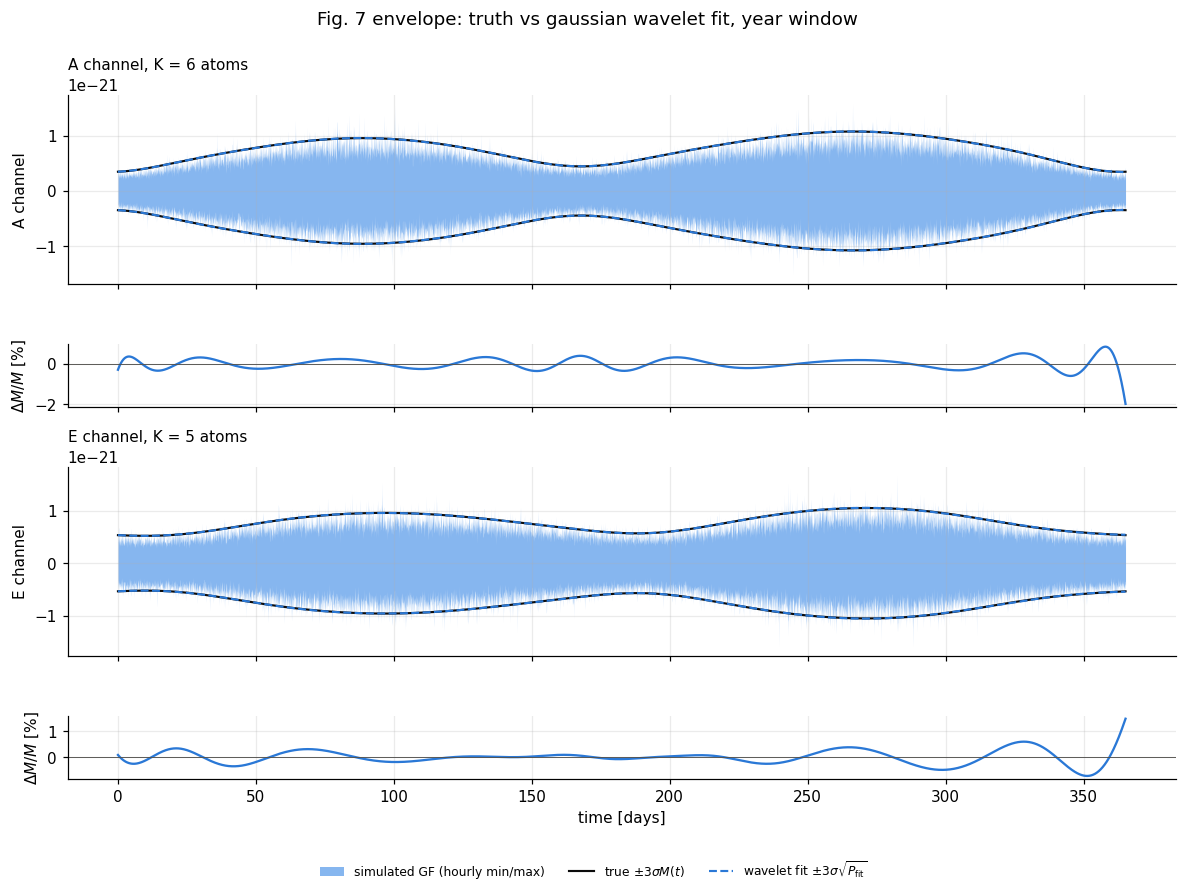

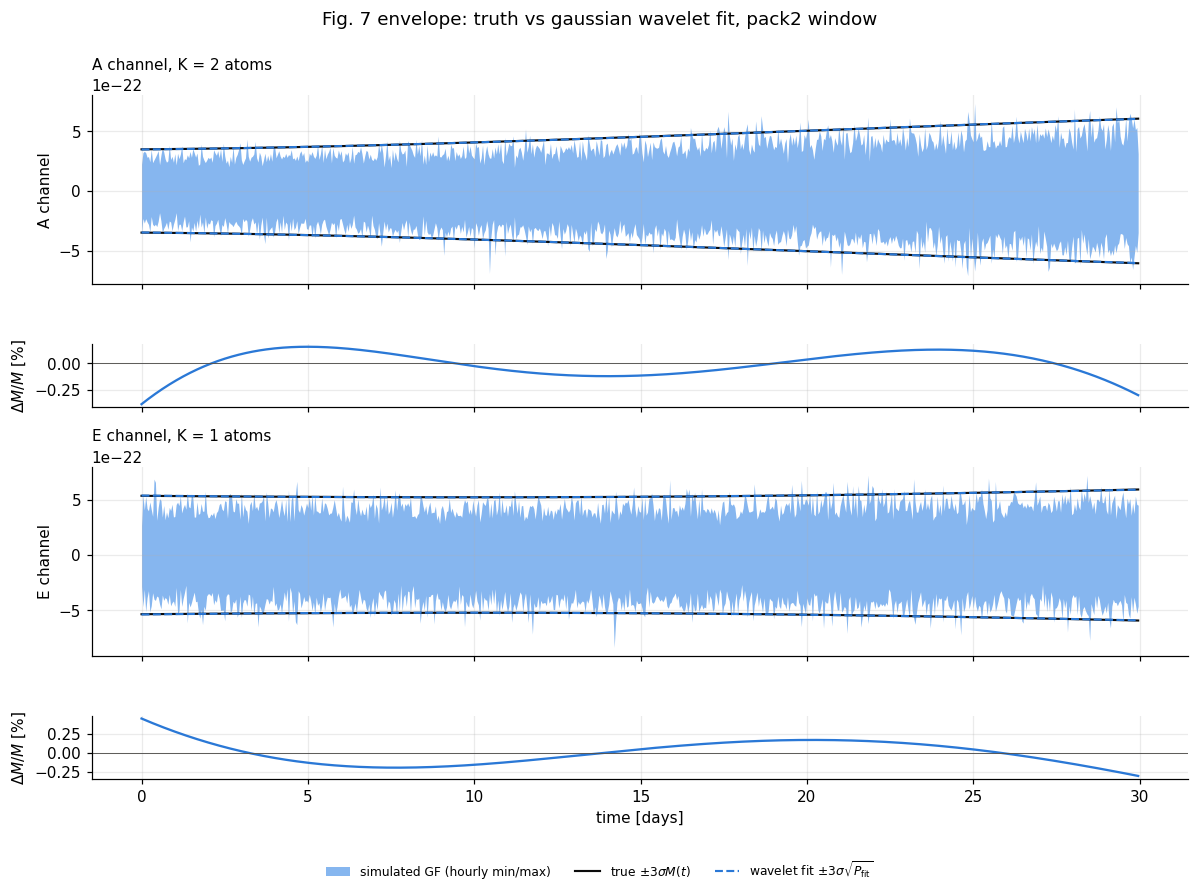

In [7]:
sigma = float(truth['sigma'])
t_band = truth['t_band']
C_DATA = '#86b6ef'

def plot_fig7_fit(window, shape='gaussian'):
    t0, T = WINDOWS[window]
    in_win = (t_band >= t0) & (t_band < t0 + T)
    fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1, 3, 1]})
    for c, ch in enumerate(CH):
        r = scan[shape, window, ch, K_SEL[shape, window, ch]]
        td = r['t'] / DAY
        M_true, M_fit = np.sqrt(r['P_true']), np.sqrt(r['P_fit'])
        ax, axr = axes[2 * c], axes[2 * c + 1]
        ax.fill_between(t_band[in_win] / DAY, truth[f'band_lo_{ch}'][in_win], truth[f'band_hi_{ch}'][in_win],
                        color=C_DATA, lw=0, rasterized=True, label='simulated GF (hourly min/max)')
        for s in (1, -1):
            ax.plot(td, s * 3 * sigma * M_true, color=C_TRUTH, lw=1.4, label=r'true $\pm3\sigma M(t)$' if s > 0 else None)
            ax.plot(td, s * 3 * sigma * M_fit, color=C_FIT, lw=1.4, ls='--',
                    label=r'wavelet fit $\pm3\sigma\sqrt{P_{\rm fit}}$' if s > 0 else None)
        ax.set_ylabel(f'{ch} channel')
        ax.set_title(f'{ch} channel, K = {K_SEL[shape, window, ch]} atoms', loc='left', fontsize=10)
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
        axr.plot(td, 100 * (M_fit / M_true - 1), color=C_FIT)
        axr.axhline(0, color=C_MUTED, lw=0.6)
        axr.set_ylabel(r'$\Delta M/M$ [%]')
        print(f"{window} {ch}: envelope residual rms {100 * np.sqrt(np.mean((M_fit / M_true - 1) ** 2)):.2f}%, "
              f"max {100 * np.max(np.abs(M_fit / M_true - 1)):.2f}%")
    axes[-1].set_xlabel('time [days]')
    fig.suptitle(f'Fig. 7 envelope: truth vs {shape} wavelet fit, {window} window', y=0.995)
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    fig.legend(*axes[0].get_legend_handles_labels(), loc='lower center', ncol=3, fontsize=8)
    fig.savefig(OUT / f'wavelet_fit_fig7_{window}_{shape}.png', bbox_inches='tight', dpi=150)

plot_fig7_fit('year')
plot_fig7_fit('pack2')

## 4. What this means for the inference

* **A-channel level.** In `WaveletPosterior` the A level is fixed at $b_A=0$ and the E level is a free `level_E`.
  For the reference atoms below to describe the same signal, the galactic amplitude has to absorb $b_A$: the injected
  `amp` in a wavelet-model analysis corresponds to $\log_{10}A + b_A/\ln 10$, and `level_E` to $b_E - b_A$.
* **Level/atom degeneracy.** An atom much wider than the window is almost constant over it, so it trades off against
  the level. In the 30-day window the widths go up to 180 d, which is why a level can sit on its $\pm2$ bound with a broad
  negative atom compensating. The modulation $P(t)$ is still well determined; the split between level and atoms is not.
  For the inference this means a ridge in the posterior and slower mixing. Options: cap `width_range_days` at about the
  window length for short windows, or accept that the atoms themselves are not identifiable and judge recovery on $P(t)$.
* **`level_E` range.** For the full year, $b_E-b_A$ lands close to the edge of the template's `level_range: [-2, 2]`
  (printed below). Widen it, e.g. to $[-3, 3]$, so the injection is not on the prior boundary.
* **Atom count.** The full year needs about as many atoms per channel as printed in §2, which is inside the template's
  `max_wavelets: 15`. The 30-day window needs only one or two. The reversible-jump posterior over $K$ should land in
  this range if the data are informative enough.

In [8]:
LN10 = np.log(10)
gf = dict(truth['gf_params'])
ref = {}
for window in WINDOWS:
    bA = unpack(scan['gaussian', window, 'A', K_SEL['gaussian', window, 'A']]['theta'], 0)[0]
    bE = unpack(scan['gaussian', window, 'E', K_SEL['gaussian', window, 'E']]['theta'], 0)[0]
    print(f"{window}: b_A = {bA:+.4f} -> effective amp = {gf['amp']:+.4f} + {bA/LN10:+.4f} = {gf['amp'] + bA/LN10:+.4f};"
          f"  level_E = b_E - b_A = {bE - bA:+.4f}")
    for ch in CH:
        K = K_SEL['gaussian', window, ch]
        theta = scan['gaussian', window, ch, K]['theta']
        ref[f'{window}_{ch}_atoms'] = theta[1:].reshape(K, 3)
        ref[f'{window}_{ch}_level'] = theta[0]
    ref[f'{window}_amp_eff'] = gf['amp'] + bA / LN10
    ref[f'{window}_level_E'] = bE - bA
    ref[f'{window}_t0'], ref[f'{window}_T'] = WINDOWS[window]

ref['rms_scan'] = np.array([(s, w, ch, K, r['rms'], r['max_rel']) for (s, w, ch, K), r in scan.items()], dtype=object)
np.savez(OUT / 'wavelet_fit_reference.npz', **ref)
print('\nsaved', OUT / 'wavelet_fit_reference.npz')

year: b_A = -0.0822 -> effective amp = -43.9431 + -0.0357 = -43.9788;  level_E = b_E - b_A = +1.9844
pack2: b_A = +1.5567 -> effective amp = -43.9431 + +0.6761 = -43.2670;  level_E = b_E - b_A = +0.4433

saved /home/krishna/bahamas_ska/data/cyclo_fig7_outputs/wavelet_fit_reference.npz


## Next: stage 3, injection and recovery

1. Simulate wavelet-domain data with the cyclo injection: `galactic_DWD_time` with pack-2 parameters, plus instrument
   noise, through `bahamas_data` with `domain: 'wavelet'`. Do this for the 30-day pack-2 window and/or the full year.
2. Run `bahamas_inference` with `modulation: wavelets`. Check that the posterior on $P_c(t)$ covers the true $M_c^2(t)$,
   that the posterior on $K$ is consistent with §2, and that `amp` recovers the effective value of §4.
3. Compare against `modulation: parametric` on the same data, and against Riccardo's chunked pack-2 posterior.